In [ ]:
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/My Drive/Ecommerce_Cleaned_Data.xlsx')

Mounted at /content/drive


# **Data exploration**

In [ ]:
#data exploration
print("First Five Rows:",df.head())

First Five Rows:    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  Ca-2016-152156 2016-11-08 2016-11-11    Second Class    Cg-12520   
1       2  Ca-2016-152156 2016-11-08 2016-11-11    Second Class    Cg-12520   
2       3  Ca-2016-138688 2016-06-12 2016-06-16    Second Class    Dv-13045   
3       4  Us-2015-108966 2015-10-11 2015-10-18  Standard Class    So-20335   
4       5  Us-2015-108966 2015-10-11 2015-10-18  Standard Class    So-20335   

     Customer Name    Segment        Country             City  ...     Sales  \
0      Claire Gute   Consumer  United States        Henderson  ...  261.9600   
1      Claire Gute   Consumer  United States        Henderson  ...  731.9400   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   14.6200   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  957.5775   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   22.3680   

   Quantity Discount    Pro

In [ ]:
print(f"date ranges is {df["Order Date"].min()} to {df["Ship Date"].max()}")

date ranges is 2014-01-03 00:00:00 to 2018-01-05 00:00:00


In [ ]:
monthly_sales = df.groupby(["Order Year","Order Month Number"])["Sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values(["Order Year","Order Month Number"])
monthly_sales["Month_Label"] = (
    monthly_sales["Order Year"].astype(str)
    + "-" +
    monthly_sales["Order Month Number"].astype(str)
)
print(monthly_sales)

    Order Year  Order Month Number        Sales Month_Label
0         2014                   1   14236.8950      2014-1
1         2014                   2    4519.8920      2014-2
2         2014                   3   57198.6410      2014-3
3         2014                   4   28166.5130      2014-4
4         2014                   5   23648.2870      2014-5
5         2014                   6   34454.9676      2014-6
6         2014                   7   33798.0790      2014-7
7         2014                   8   27892.1285      2014-8
8         2014                   9   81414.9708      2014-9
9         2014                  10  129521.8010     2014-10
10        2014                  11   78576.6527     2014-11
11        2014                  12   69797.4105     2014-12
12        2015                   1   18174.0756      2015-1
13        2015                   2   11308.8290      2015-2
14        2015                   3   37512.7076      2015-3
15        2015                   4   338

# **Line Chart**

1.   Monthly Sales Trend




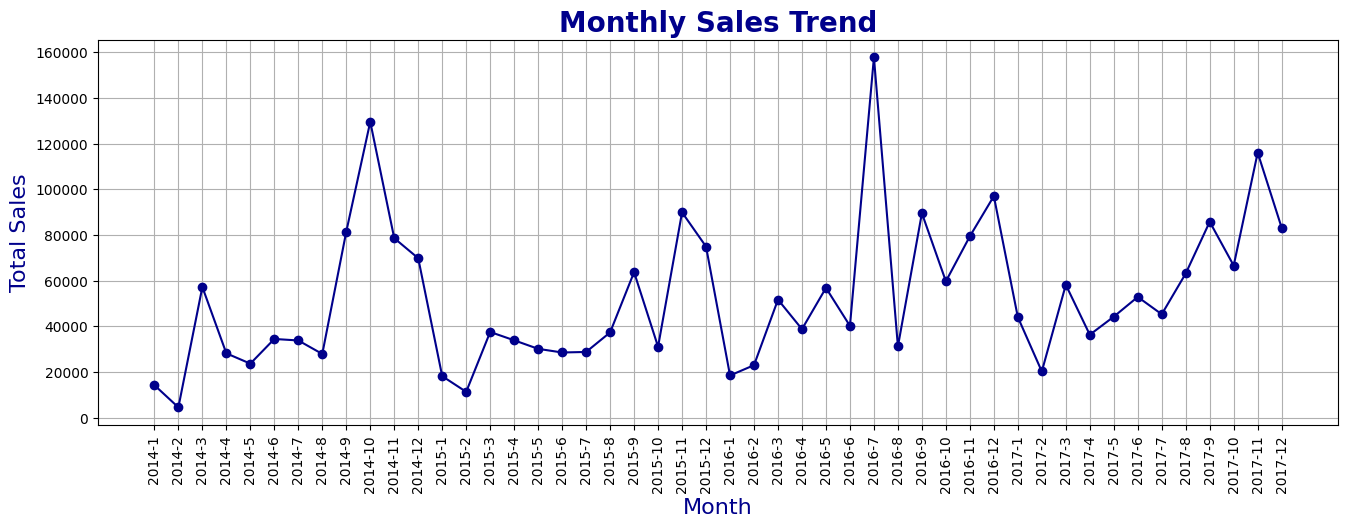

In [ ]:
plt.figure(figsize=(16,5))
plt.plot(
    monthly_sales["Month_Label"],
    monthly_sales["Sales"],
    marker ="o",
    color="darkblue"
)
plt.xlabel("Month",color="darkblue", fontsize = 16,)
plt.ylabel("Total Sales",color="darkblue", fontsize = 16,)
plt.title(
    "Monthly Sales Trend",
    fontsize = 20,
    color="darkblue",
    fontweight="bold"

)
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

In [ ]:
df["Category"] = df["Category"].str.title()
sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).reset_index()
print(sales_by_category)

          Category        Sales
0       Technology  921516.9890
1        Furniture  872884.5089
2  Office Supplies  732970.2300


# **Bar Chart**

1.   **Sales by Category**



/tmp/ipykernel_1185/2561734520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


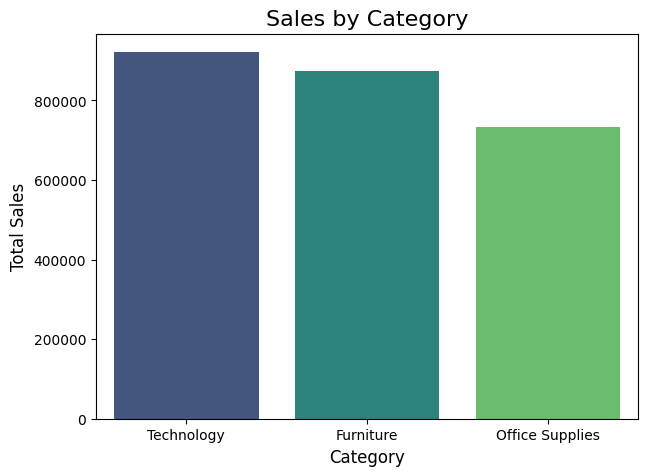

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x="Category",
    y="Sales",
    data=sales_by_category,
    palette="viridis"
)
plt.xlabel("Category",fontsize=12)
plt.ylabel("Total Sales",fontsize=12)
plt.title("Sales by Category",fontsize=16)
plt.show()

In [ ]:
Profit_by_category=df.groupby("Category")["Profit"].sum().reset_index()
print(Profit_by_category)

          Category       Profit
0        Furniture   18179.4889
1  Office Supplies  122816.8196
2       Technology  140863.6819



2. Sales By Region



In [ ]:
#summary DataFrame containing total sales for each region
sales_by_region = (
    df.groupby("Region")["Sales"]
    .sum().sort_values(ascending=False).reset_index()
    )
print(sales_by_region)

    Region        Sales
0     West  752987.6825
1     East  666026.8740
2  Central  596621.1304
3    South  511736.0410


## **📊Visualization**

/tmp/ipykernel_1185/2897052887.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


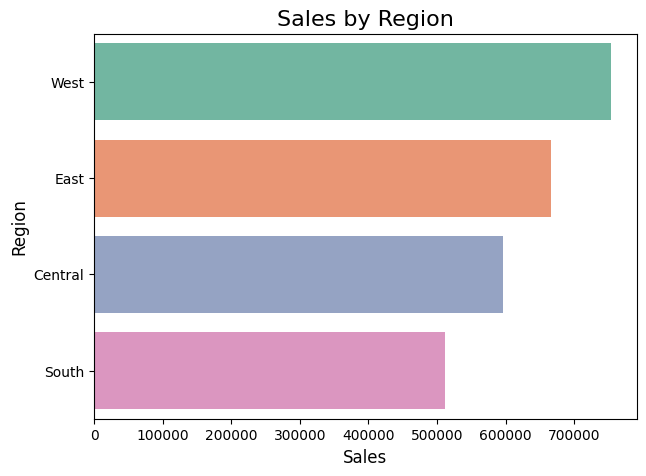

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x="Sales",
    y="Region",
    data=sales_by_region,
    palette="Set2"
)
plt.xlabel("Sales",fontsize=12)
plt.ylabel("Region",fontsize=12)
plt.title("Sales by Region",fontsize=16)
plt.show()

### **Business Insight💼**
The West Region generates the highest sales, so the company should analyze the products, marketing strategies, and customer behavior in this region



3.   Profit by Category


  





In [ ]:
profit_by_category = (
    df.groupby("Category")["Profit"].sum().sort_values(ascending=False).reset_index()
)
print(profit_by_category)

          Category       Profit
0       Technology  140863.6819
1  Office Supplies  122816.8196
2        Furniture   18179.4889


## **📊Visualization**

/tmp/ipykernel_405/1742888431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


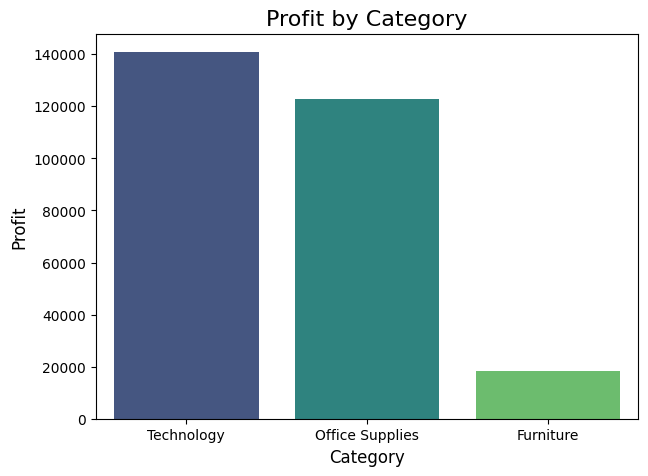

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    x="Category",
    y="Profit",
    data= profit_by_category,
    palette="viridis"
)
plt.xlabel("Category",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Profit by Category",fontsize=16)
plt.show()

## **Business Insight 💼**

Technology generates the highest profit, so the company should continue investing in that category

### **4.Sales by Segment**

In [ ]:
sales_by_segment = (
    df.groupby("Segment")["Sales"].sum().sort_values(ascending= False).reset_index()
)
print(sales_by_segment)

       Segment         Sales
0     Consumer  1.402138e+06
1    Corporate  7.020530e+05
2  Home Office  4.231803e+05


#####**📊Visualization**

/tmp/ipykernel_405/1529507978.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


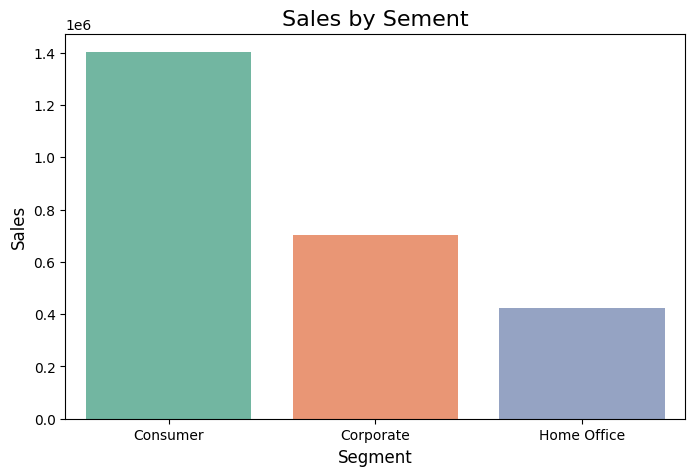

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Segment",
    y="Sales",
    data=sales_by_segment,
    palette="Set2"
)
plt.xlabel("Segment",fontsize = 12)
plt.ylabel("Sales",fontsize = 12)
plt.title("Sales by Sement",fontsize =16)
plt.show()

### **💼Business Insight**
  Consumer segment generates the highest sales, the company should focus more marketing campaigns on Consumer customers.

### **5. Sales by Sub-Category**

In [ ]:
#summarize
profit_by_subcategory = (
    df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).reset_index()
)
print(profit_by_subcategory)

   Sub-Category      Profit
0       Copiers  51697.8361
1        Phones  44180.3666
2   Accessories  41797.4636
3         Paper  33893.9201
4       Binders  30863.7847
5        Chairs  26336.9708
6       Storage  21262.8542
7    Appliances  18051.3931
8   Furnishings  12957.3832
9     Envelopes   6923.8417
10          Art   6510.5500
11       Labels   5536.3105
12     Machines   3188.0156
13    Fasteners    956.4926
14     Supplies  -1182.3273
15    Bookcases  -3459.3964
16       Tables -17655.4687


**📊Visualization**

/tmp/ipykernel_405/4110279524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


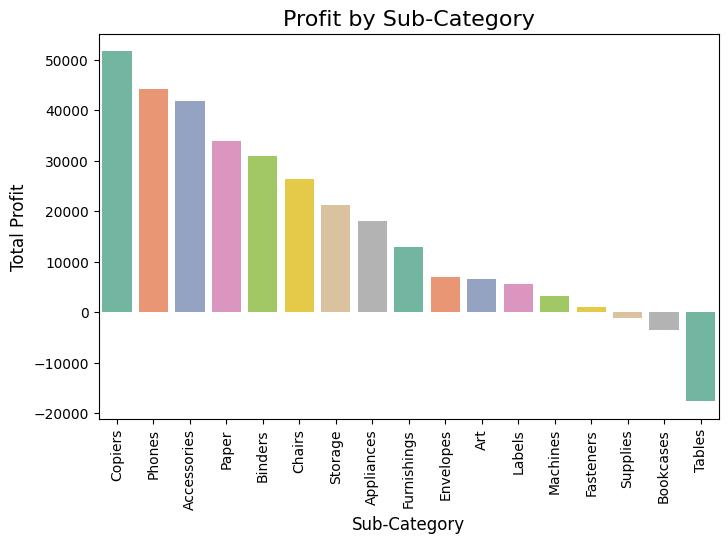

In [ ]:

plt.figure(figsize=(8,5))
sns.barplot(
    x="Sub-Category",
    y="Profit",
    data=profit_by_subcategory,
    palette="Set2"
)
plt.xlabel("Sub-Category",fontsize = 12)
plt.ylabel("Total Profit",fontsize = 12)
plt.title("Profit by Sub-Category",fontsize =16)
plt.xticks(rotation=90)
plt.show()

### **💼Business Insight**

1.Copiers are genrating the more profit,the company should invest also in sub catgory

2.Tables are genrating loss, company should check the main concern under this sub category and manage the stocks

# **Histogram**
1.Sales Distribution

In [ ]:
#validation
print(df["Sales"].describe())

count      9954.000000
mean        253.905136
std        1703.389345
min           0.444000
25%          17.340000
50%          54.594000
75%         209.769000
max      121504.000000
Name: Sales, dtype: float64


**📊Visualization**

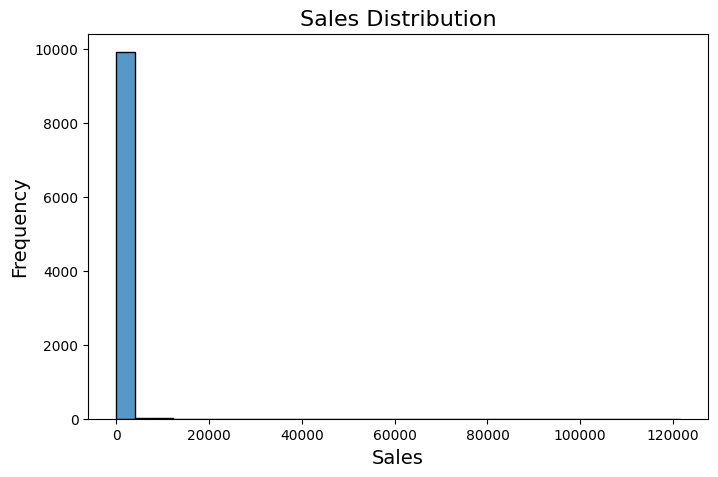

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Sales"],
    bins=30
)
plt.xlabel("Sales",fontsize = 14)
plt.ylabel("Frequency",fontsize = 14)
plt.title("Sales Distribution",fontsize = 16)
plt.show()

**💼Business Insight**

2. Profit Distribution

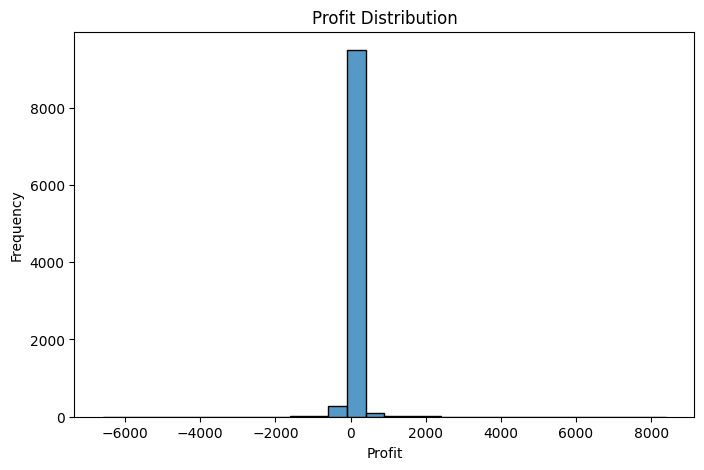

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit"],
    bins=30
)

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.title("Profit Distribution")

plt.show()

**💼Business Insight**

Most orders generate profits close to zero, while only a few transactions produce extremely high profits or losses. This indicates that profit is unevenly distributed across orders

# **Box Plot**
Profit Outlier Detection

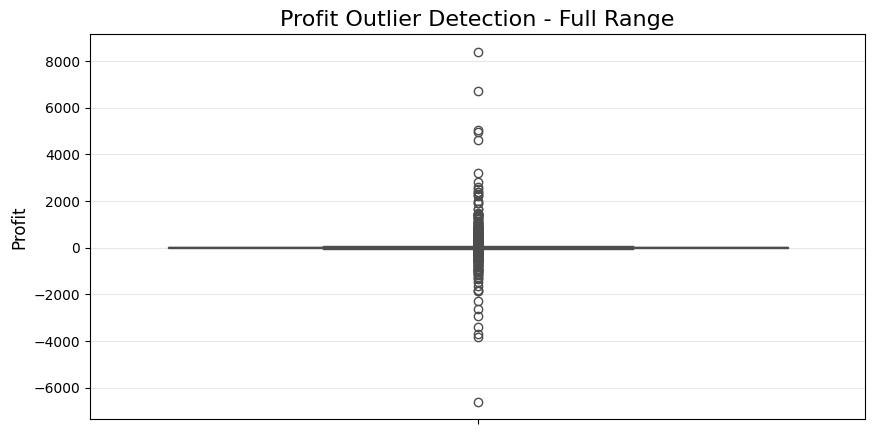

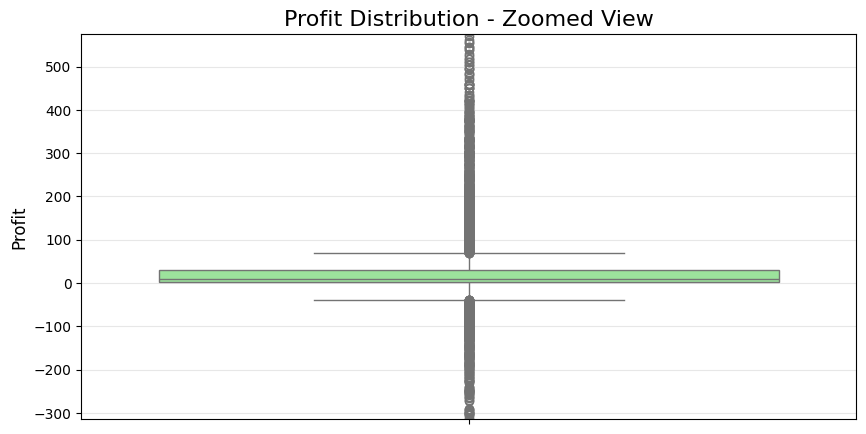

In [ ]:
# Full Range Box Plot - Shows all outliers
plt.figure(figsize=(10, 5))

sns.boxplot(
    y="Profit",
    data=df,
    color="red"
)

plt.ylabel("Profit", fontsize=12)
plt.title("Profit Outlier Detection - Full Range", fontsize=16)
plt.grid(axis="y", alpha=0.3)

plt.show()


# Zoomed Box Plot - Focuses on the normal profit range
plt.figure(figsize=(10, 5))

sns.boxplot(
    y="Profit",
    data=df,
    color="lightgreen"
)

plt.ylim(
    df["Profit"].quantile(0.01),
    df["Profit"].quantile(0.99)
)

plt.ylabel("Profit", fontsize=12)
plt.title("Profit Distribution - Zoomed View", fontsize=16)
plt.grid(axis="y", alpha=0.3)

plt.show()

# **💼Business Insight**

1.Profit contains significant outliers.

2.Most orders fall within a much smaller profit range.

3.The distribution is likely right/left skewed because of extreme values.



# **Count Plot**
Number of Orders by Region

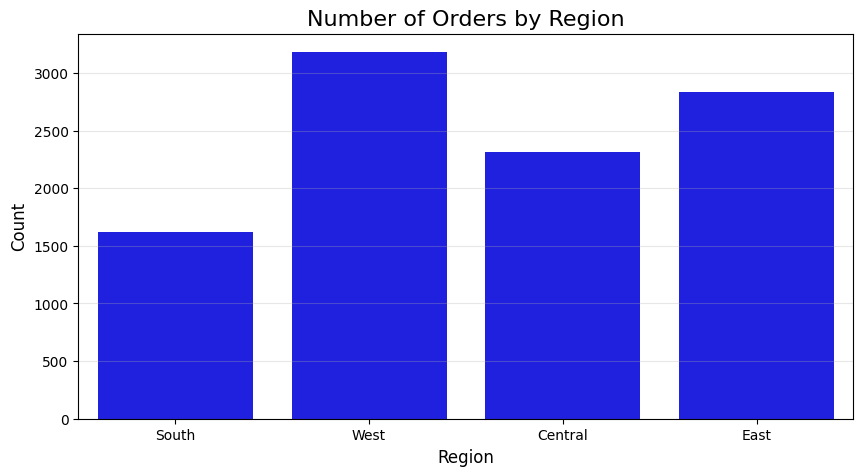

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x="Region",
    data=df,
    color="blue"
)
plt.xlabel("Region",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.title("Number of Orders by Region",fontsize=16)
plt.grid(axis="y", alpha=0.3)
plt.show()

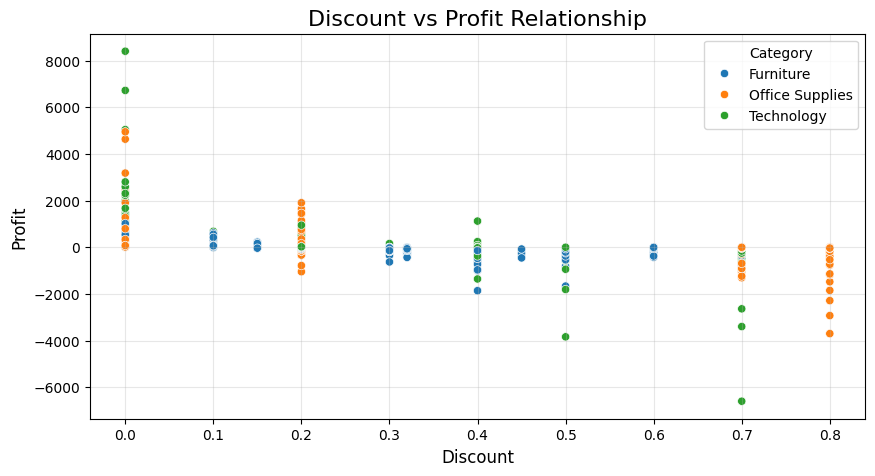

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="Discount",
    y="Profit",
    data=df,
    color="blue",
    hue="Category"
)
plt.xlabel("Discount",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Discount vs Profit Relationship",fontsize=16)
plt.grid(alpha=0.3)
plt.show()

# **Heat Map**

In [ ]:
#Correaltion heatmap
numerical_data = df.select_dtypes(include="number")
numeric_matrix= numerical_data.corr()
print(numeric_matrix)

                      Row ID  Postal Code     Sales  Quantity  Discount  \
Row ID              1.000000     0.009536 -0.003531 -0.004625  0.013642   
Postal Code         0.009536     1.000000 -0.005487  0.013030  0.058571   
Sales              -0.003531    -0.005487  1.000000  0.089979 -0.015114   
Quantity           -0.004625     0.013030  0.089979  1.000000  0.008383   
Discount            0.013642     0.058571 -0.015114  0.008383  1.000000   
Profit              0.013691    -0.028504  0.193077  0.067401 -0.221314   
Order Year          0.014886     0.004279 -0.012323 -0.004967 -0.003068   
Order Month Number -0.018886     0.026566  0.002346  0.023548 -0.005940   
Delivery Days      -0.001642    -0.010148  0.000601  0.017467  0.000628   
Profit Margin      -0.021464    -0.064724 -0.003077 -0.005445 -0.855469   

                      Profit  Order Year  Order Month Number  Delivery Days  \
Row ID              0.013691    0.014886           -0.018886      -0.001642   
Postal Code     

# **Visuilization📊**

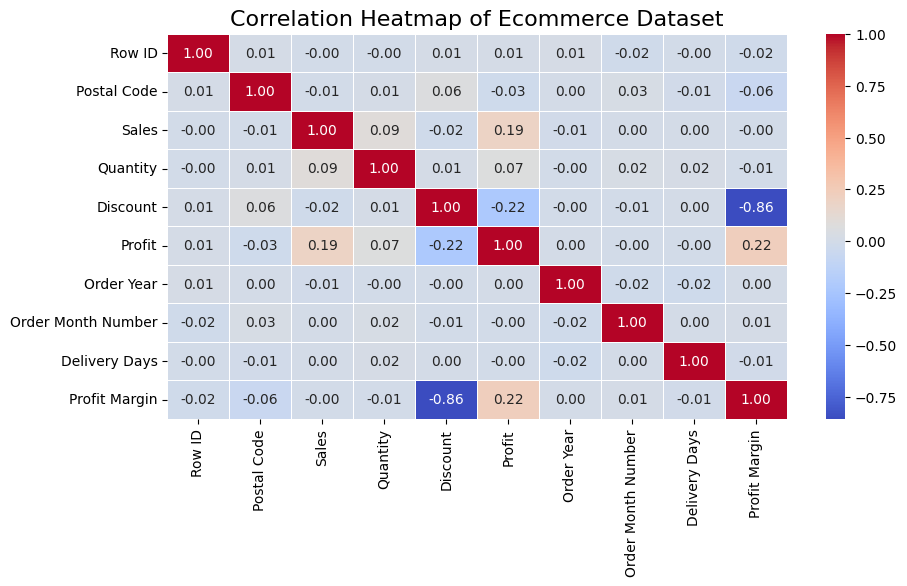

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(
    numeric_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Ecommerce Dataset",fontsize=16)
plt.show()

# **Business Insight**
1.Sales and Profit are strongly and positively correlated.

2.Higher discounts are associated with lower profits.

3.The current discount strategy should be reviewed to improve profitability.

4.Key variables such as Sales, Quantity, Discount, Delivery Days, and Profit Margin can be used for profit prediction.

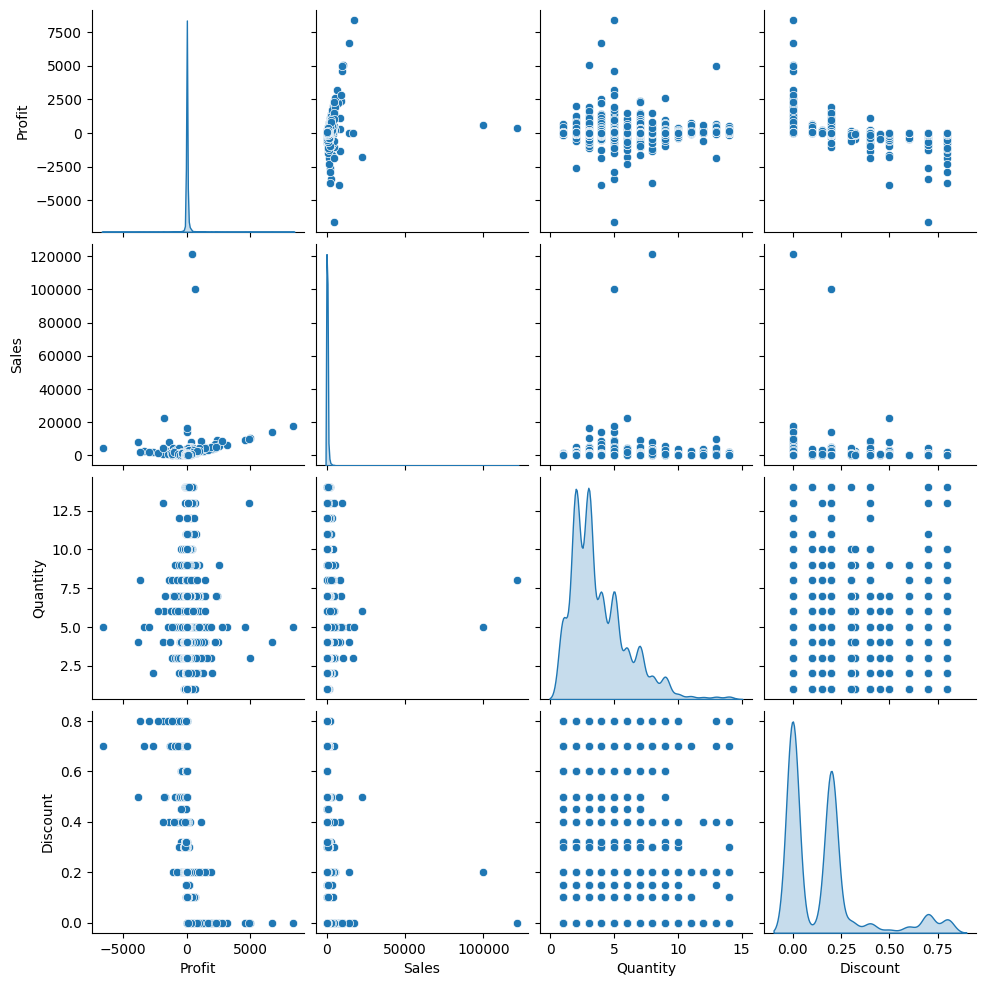

In [ ]:
columns= ["Profit","Sales","Quantity","Discount"]
sns.pairplot(
    df[columns],
    diag_kind="kde"
)
plt.show()


# **Business Insight**
1. Sales and Profit have a positive relationship.
2. Higher discounts appear to reduce profit.
3. Most orders have low sales values.
4. Most customers purchase small quantities.
5. Discounts are concentrated at specific levels.
6. There are several outliers in the dataset.

# **🔵Correlation Analysis of Key Business Metrics**

## **Visuilization📊**

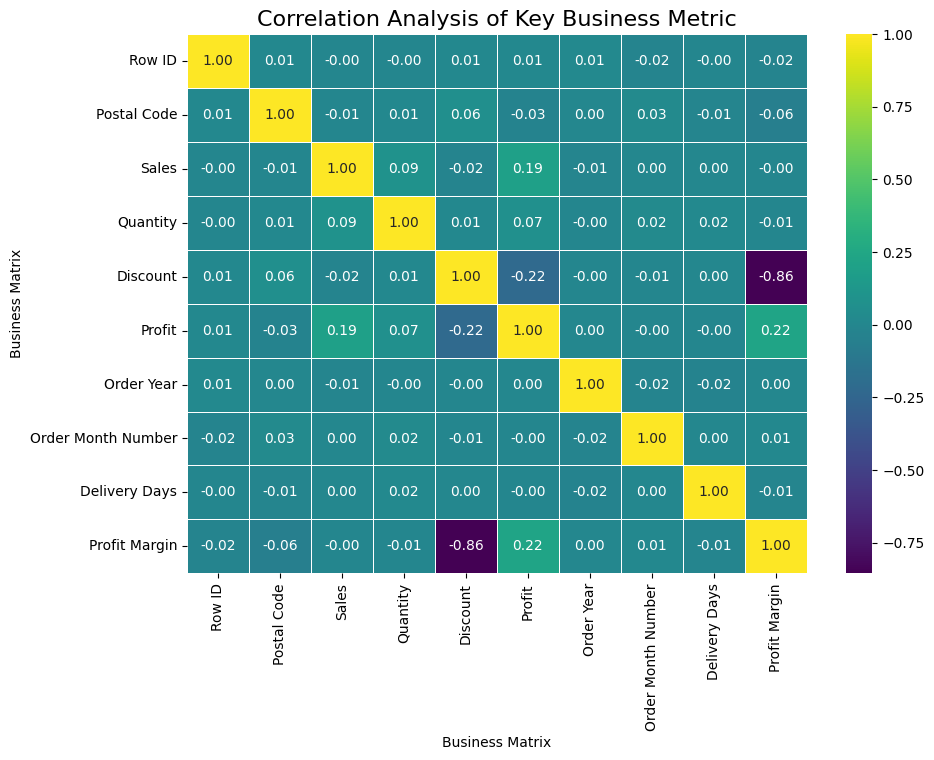

In [ ]:
#Selecting the relevant numerical variables
correlation_data=(
    "Sales","Quantity","Discount","Delivery Days","Profit","Profit Margin"
)
#calculating the correlation matrix
correlartion_matrix =df[list(correlation_data)].corr()

# Creating correlaiton heat map
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths =0.5,
)

plt.title("Correlation Analysis of Key Business Metric",fontsize=16)
plt.xlabel("Business Matrix")
plt.ylabel("Business Matrix")
plt.show()



# **Business Insight**
1.Discount and Profit Margin show a strong negative correlation (-0.86), indicating that higher discounts are associated with lower profitability.

2.Sales and Profit have a weak positive correlation (0.19), suggesting that higher sales do not necessarily translate into significantly higher profits.

3.Quantity and Profit show almost no linear relationship (0.07), indicating that increasing sales volume alone may not improve profitability.

4.The business should focus on optimizing discounts, pricing, and profit margins rather than relying solely on increasing sales volume.**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>